# Task 2.2 - CNN Image Classifier

## Objective
Build and train a Convolutional Neural Network (CNN) in PyTorch to classify clothing
images from the Fashion-MNIST dataset into 10 categories.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Torch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


## Load Dataset

We use the Fashion-MNIST dataset (built into torchvision) — 28x28 grayscale images
of clothing items across 10 categories. Images are converted to tensors and pixel
values are normalized.

In [2]:
# Define transform: convert image to tensor, normalize pixel values to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download train and test sets
train_data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_data = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

100.0%
100.0%
100.0%
100.0%

Train samples: 60000
Test samples: 10000


## Inspect Sample Images

Before building the model, we look at a few sample images and their labels to
understand what the model will be learning to classify.

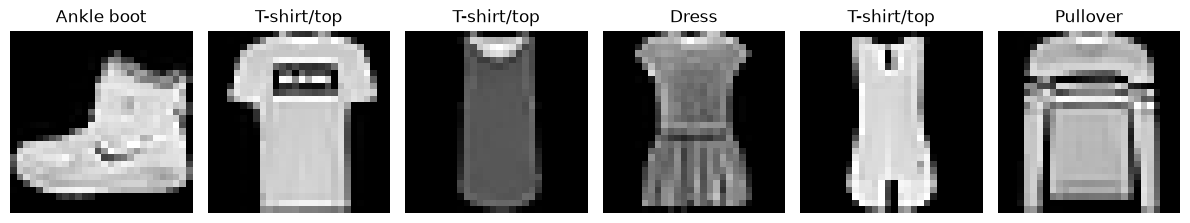

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## DataLoaders

We wrap the train and test datasets in DataLoaders to feed data in batches during
training and evaluation.

In [4]:
batch_size = 64

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Quick check
sample_images, sample_labels = next(iter(train_loader))
print("Batch images shape:", sample_images.shape)
print("Batch labels shape:", sample_labels.shape)

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


## Define the CNN

We build a small CNN with two convolutional layers (each followed by ReLU and max
pooling), then flatten and pass through fully connected layers for classification.

In [5]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected (classifier) layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))  # 14x14 -> 7x7
        x = x.view(x.size(0), -1)             # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNNClassifier()
print(model)

CNNClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Loss Function and Optimizer

We use CrossEntropyLoss since this is a multi-class classification problem (10
categories), and Adam as the optimizer.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Training Loop

We train for several epochs, tracking loss and accuracy on the training set each epoch.

In [7]:
num_epochs = 10
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}")

Epoch 1/10 - Loss: 0.4732 - Accuracy: 0.8305
Epoch 2/10 - Loss: 0.3036 - Accuracy: 0.8897
Epoch 3/10 - Loss: 0.2593 - Accuracy: 0.9052
Epoch 4/10 - Loss: 0.2304 - Accuracy: 0.9157
Epoch 5/10 - Loss: 0.2078 - Accuracy: 0.9236
Epoch 6/10 - Loss: 0.1860 - Accuracy: 0.9306
Epoch 7/10 - Loss: 0.1663 - Accuracy: 0.9387
Epoch 8/10 - Loss: 0.1493 - Accuracy: 0.9448
Epoch 9/10 - Loss: 0.1338 - Accuracy: 0.9501
Epoch 10/10 - Loss: 0.1197 - Accuracy: 0.9552


## Evaluation on Test Set

We evaluate the trained model on the test set (images it has never seen) to check
how well it generalizes.

In [8]:
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2581
Test Accuracy: 0.9164


## Training Curves

Visualizing loss and accuracy over epochs to confirm stable, healthy training.

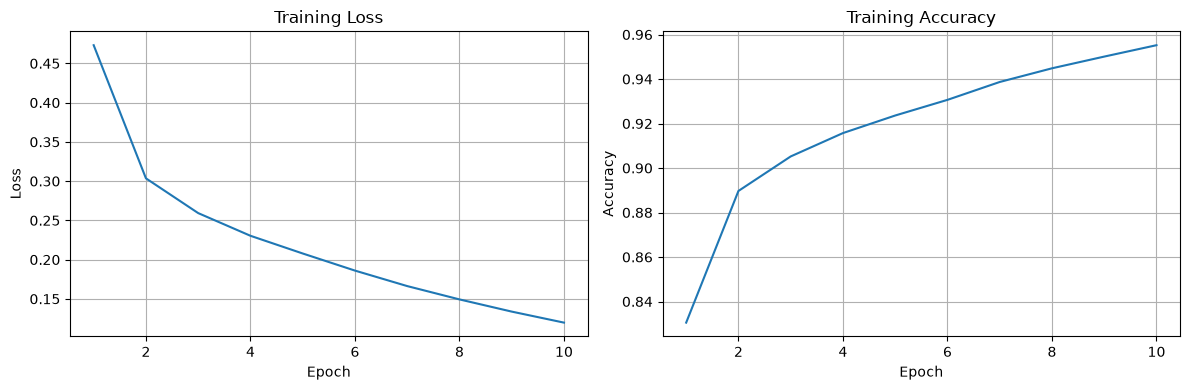

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, num_epochs+1), train_losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(True)

axes[1].plot(range(1, num_epochs+1), train_accuracies)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Sample Predictions

We display a few test images alongside their predicted and actual labels, including
both correct and incorrect examples.

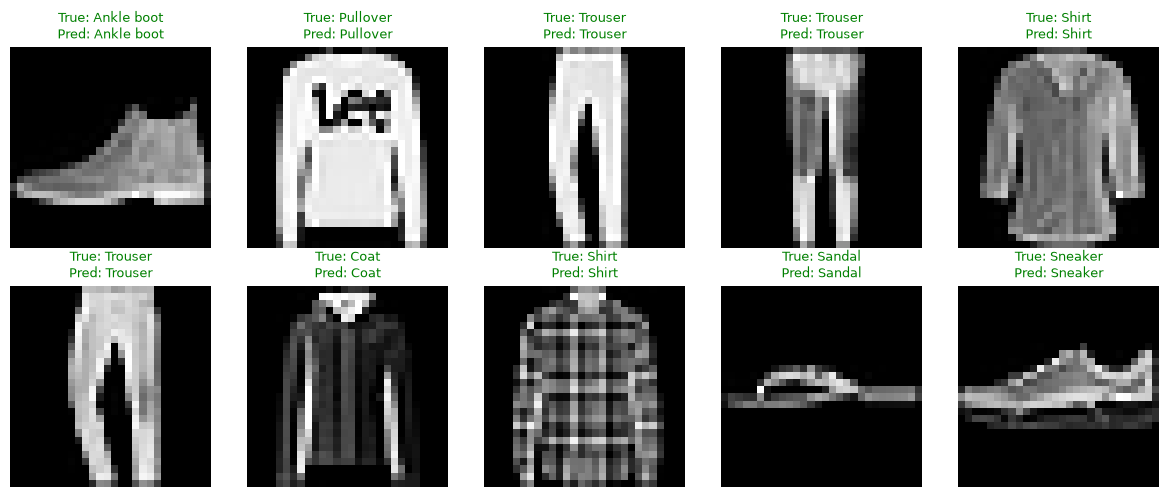

In [10]:
model.eval()
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    img = images[i].squeeze()
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]
    color = "green" if predicted[i] == labels[i] else "red"

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=9)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Save the Trained Model

We save the trained model's weights so it can be reloaded later without retraining.

In [11]:
import os

model_path = "../models/cnn_fashion_mnist.pth"
torch.save(model.state_dict(), model_path)

print("Model saved to:", model_path)
print("File exists:", os.path.exists(model_path))

Model saved to: ../models/cnn_fashion_mnist.pth
File exists: True


## Conclusion

We built a CNN in PyTorch with two convolutional layers (16 and 32 filters) followed
by max pooling and fully connected layers, to classify Fashion-MNIST images into 10
clothing categories.

- Final training accuracy: ~95.5%
- Test accuracy: ~91.6%
- The gap between train and test accuracy is small and expected, indicating the model
  generalizes reasonably well without significant overfitting.
- Sample predictions show the model correctly classifies most clothing items, including
  visually similar categories like shirts vs coats.

**What I learned:** how convolution and pooling layers extract and compress spatial
features from images, how image tensor shapes (batch, channels, height, width) differ
from tabular data, and how to save/load a trained PyTorch model using state_dict().

**Possible improvements:** trying more epochs, data augmentation, or a deeper
architecture to push accuracy higher.